Файл имитирует исполнение (EXEC):

[x] есть датакласс в чей представитель - данные о состоянии ЦПК

[x] есть датакласс о всех возможных статусах ребутов

[x] есть датакласс в чей представитель - данные о состоянии ребута ЦПК

назначаем task (+ проверяем как он хранит объекты) -> назначаем что мы хотим посмотреть по ДАННОМУ результату result + его печать

In [2]:
# SABX__models.ipynb
# Цель: черновик контрактов данных PCReboot.
#
# Здесь мы НЕ делаем reboot.
# Здесь мы описываем данные:
# - что программа принимает: RebootTask
# - что программа возвращает: RebootResult
# - какие статусы допустимы: RebootStatus

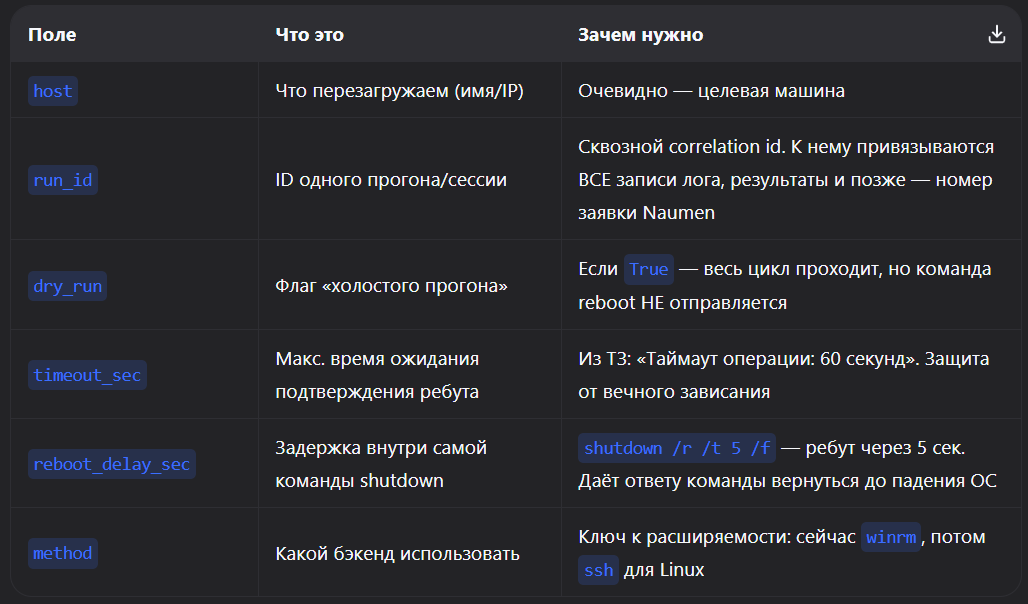

PROC: models.py

In [3]:
"""DATA: -> ok
host = WS-K534D
run_id = run-0001
status = REBOOT_CONFIRMED
message = ...
started_at = ...
finished_at = ...
duration_ms = ...
dry_run = ...
method = ...
"""
from dataclasses import dataclass

@dataclass
class RebootTask:
    """
    Задача на перезагрузку одного хоста.

    Это входной объект для core.
    CLI или будущий бот создаёт такой объект и передаёт в ядро.
    """
    
    host: str #хост ЦПК
    run_id: str #название сессии
    dry_run: bool = True #безопасный ли режим 
    timeout_sec: int = 60 #таймаут операции
    reboot_delay_sec: int = 5 #	задержка для shutdown /r /t 5
    method: str = "winrm" #транспорт: winrm



PROC:IMIT reboot.py:

In [4]:
task = RebootTask(
    host="WS-K534D",
    run_id="run-0001"
)

print(task)

RebootTask(host='WS-K534D', run_id='run-0001', dry_run=True, timeout_sec=60, reboot_delay_sec=5, method='winrm')


PROC: models.py

In [5]:
from enum import Enum 

class RebootStatus(str, Enum):
    """
    Допустимые статусы обработки одной задачи перезагрузки.
    """

    PENDING = "PENDING"
    VALIDATION_FAILED = "VALIDATION_FAILED"
    NOT_ALLOWED = "NOT_ALLOWED"
    PRECHECK_FAILED = "PRECHECK_FAILED"
    AUTH_ERROR = "AUTH_ERROR"
    COMMAND_SENT = "COMMAND_SENT"
    REBOOT_CONFIRMED = "REBOOT_CONFIRMED"
    TIMEOUT = "TIMEOUT"
    COMMAND_ERROR = "COMMAND_ERROR"
    SKIPPED = "SKIPPED"
    UNKNOWN_ERROR = "UNKNOWN_ERROR"

PROC:IMIT reboot.py:

In [6]:
print(RebootStatus.PENDING)
print(RebootStatus.PENDING.value)

RebootStatus.PENDING
PENDING


PROC: models.py

In [7]:
from datetime import datetime
from typing import Optional 

@dataclass
class RebootResult:
    """
    Результат обработки одной задачи перезагрузки.

    Этот объект будет возвращаться ядром.
    CLI будет показывать его пользователю.
    Логгер будет писать его в JSONL.
    """
    
    host: str
    run_id: str
    status: RebootStatus
    message: str #перезагр/нет
    started_at: Optional[datetime] = None
    finished_at: Optional[datetime] = None
    duration_ms: Optional[int] = None
    dry_run: bool = True
    method: str = "winrm"  

PROC:IMIT reboot.py:

In [8]:
result = RebootResult(
    host=task.host,
    run_id=task.run_id,
    status=RebootStatus.PENDING,
    message="Задача создана. Reboot ещё не отправлялся.",
    dry_run=task.dry_run,
    method=task.method
)

print(result)

RebootResult(host='WS-K534D', run_id='run-0001', status=<RebootStatus.PENDING: 'PENDING'>, message='Задача создана. Reboot ещё не отправлялся.', started_at=None, finished_at=None, duration_ms=None, dry_run=True, method='winrm')


[x] RebootTask существует
[x] RebootStatus существует
[x] RebootResult существует
[x] объекты создаются
[x] объекты печатаются
[x] видна связь task -> result